In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", plt.matplotlib.__version__)
print("Seaborn     :", sns.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib      :", joblib.__version__)

print("\n✅ All libraries are working!")

NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Seaborn     : 0.13.2
Scikit-learn: 1.6.1
Joblib      : 1.6.0

✅ All libraries are working!


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

display(df.head())

Saving student_performance_recommended_final.csv to student_performance_recommended_final (2).csv
Dataset loaded successfully!
File: student_performance_recommended_final (2).csv
Shape: (1005, 8)


,Student_ID,Attendance,Internal_Marks,Assignment_Submissions,Learning_Platform_Activity,Previous_Performance,Course,Performance_Status
0,STU0001,86.6,54.5,50.9,63.6,72.2,MECH,Average
1,STU0002,78.8,63.4,56.7,64.1,63.0,EEE,Average
2,STU0003,78.8,60.4,43.3,57.0,58.7,EEE,Average
3,STU0004,76.7,68.4,66.0,65.5,69.5,MECH,Average
4,STU0005,88.9,76.3,59.4,67.7,73.1,EEE,Good


In [ ]:
required_columns = [
    "Student_ID",
    "Attendance",
    "Internal_Marks",
    "Assignment_Submissions",
    "Learning_Platform_Activity",
    "Previous_Performance",
    "Course",
    "Performance_Status"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDuplicate Student IDs:", df["Student_ID"].duplicated().sum())

print("\nPerformance Distribution:")
display(df["Performance_Status"].value_counts())

Dataset Shape: (1005, 8)

Data Types:
Student_ID                     object
Attendance                    float64
Internal_Marks                float64
Assignment_Submissions        float64
Learning_Platform_Activity    float64
Previous_Performance          float64
Course                         object
Performance_Status             object
dtype: object

Missing Values:


,Missing Values
Student_ID,0
Attendance,0
Internal_Marks,5
Assignment_Submissions,5
Learning_Platform_Activity,5
Previous_Performance,5
Course,0
Performance_Status,0



Duplicate Rows: 5

Duplicate Student IDs: 5

Performance Distribution:


,count
Performance_Status,
Average,252
Excellent,252
Good,251
At Risk,250


In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove duplicate Student IDs
df_clean = df_clean.drop_duplicates(
    subset=["Student_ID"],
    keep="first"
)

# Convert numerical columns
numeric_columns = [
    "Attendance",
    "Internal_Marks",
    "Assignment_Submissions",
    "Learning_Platform_Activity",
    "Previous_Performance"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

# Keep values within 0–100
for col in numeric_columns:
    df_clean[col] = df_clean[col].clip(0, 100)

# Attendance requirement from the problem statement
df_clean = df_clean[
    df_clean["Attendance"].isna() |
    (df_clean["Attendance"] > 75)
]

print("Cleaned Dataset Shape:", df_clean.shape)

print("\nRemaining Missing Values:")
display(df_clean.isnull().sum().to_frame("Missing Values"))

Cleaned Dataset Shape: (1000, 8)

Remaining Missing Values:


,Missing Values
Student_ID,0
Attendance,0
Internal_Marks,5
Assignment_Submissions,5
Learning_Platform_Activity,5
Previous_Performance,5
Course,0
Performance_Status,0


In [ ]:
print("Descriptive Statistics")

display(
    df_clean[numeric_columns].describe().round(2)
)

Descriptive Statistics


,Attendance,Internal_Marks,Assignment_Submissions,Learning_Platform_Activity,Previous_Performance
count,1000.00,995.00,995.00,995.00,995.00
mean,82.41,66.60,66.79,64.52,65.09
std,6.10,15.89,18.78,19.87,16.35
min,75.10,28.40,20.80,10.00,20.00
25%,77.20,54.15,52.05,48.60,52.95
50%,80.50,67.10,68.00,66.40,65.80
75%,86.50,79.35,82.80,81.00,78.35
max,100.00,100.00,100.00,100.00,100.00


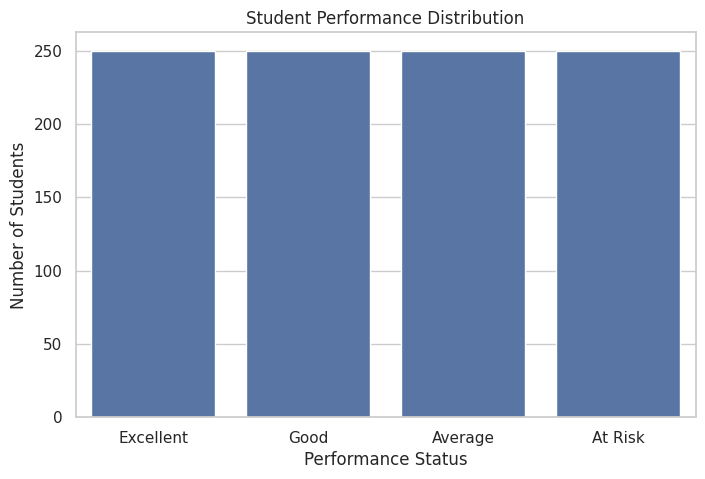

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Performance_Status",
    order=["Excellent", "Good", "Average", "At Risk"]
)

plt.title("Student Performance Distribution")
plt.xlabel("Performance Status")
plt.ylabel("Number of Students")

plt.show()

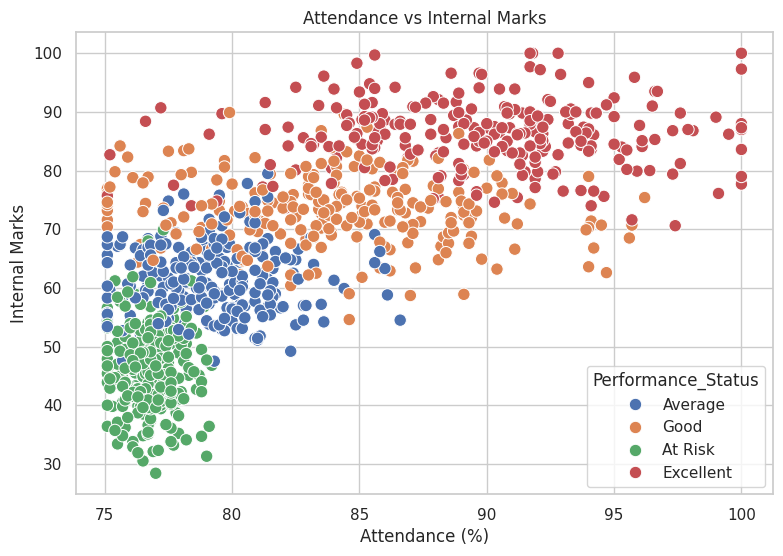

Correlation between Attendance and Internal Marks: 0.726


In [ ]:
# Attendance vs Internal Marks
plt.figur
e(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Internal_Marks",
    hue="Performance_Status",
    s=80
)

plt.title("Attendance vs Internal Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Internal Marks")

plt.show()

correlation = df_clean[
    ["Attendance", "Internal_Marks"]
].corr().iloc[0, 1]

print(f"Correlation between Attendance and Internal Marks: {correlation:.3f}")

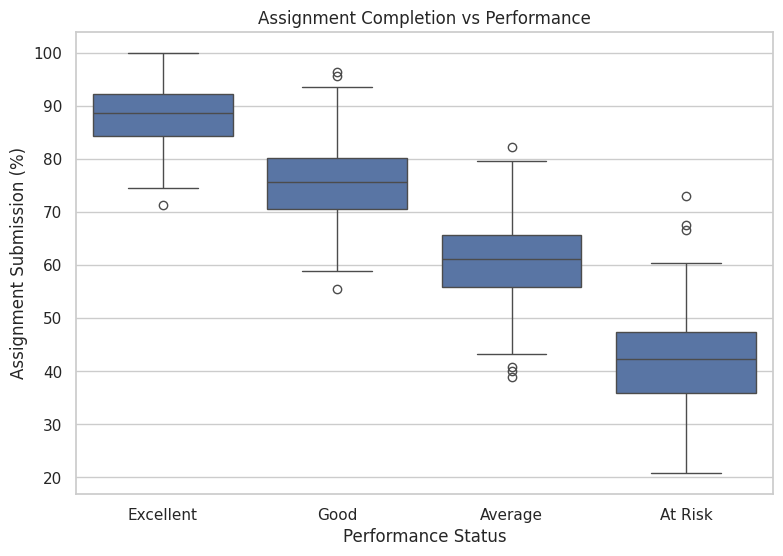

In [ ]:
# Assignment completion vs performance

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Performance_Status",
    y="Assignment_Submissions",
    order=["Excellent", "Good", "Average", "At Risk"]
)

plt.title("Assignment Completion vs Performance")
plt.xlabel("Performance Status")
plt.ylabel("Assignment Submission (%)")

plt.show()

In [ ]:
assignment_analysis = (
    df_clean
    .groupby("Performance_Status")["Assignment_Submissions"]
    .mean()
    .reindex(["Excellent", "Good", "Average", "At Risk"])
)

display(
    assignment_analysis
    .round(2)
    .to_frame("Average Assignment Submission")
)

,Average Assignment Submission
Performance_Status,
Excellent,88.45
Good,75.49
Average,60.82
At Risk,42.33


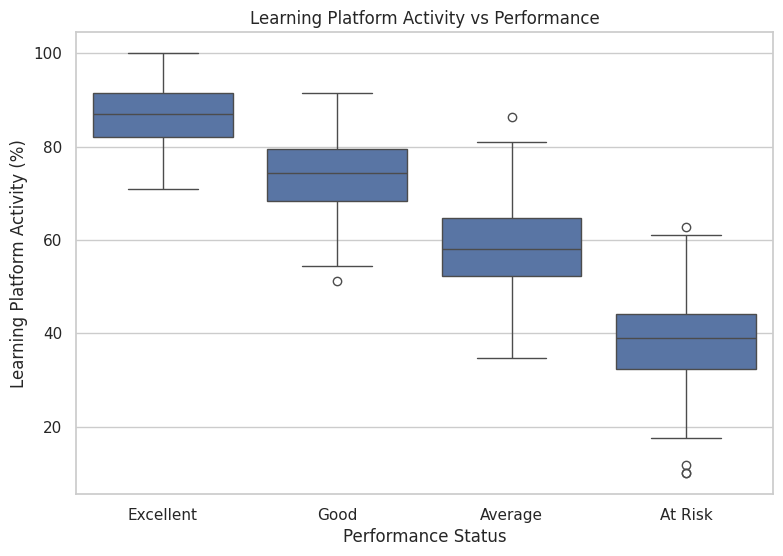

In [ ]:
#Learning-platform activity vs performance
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Performance_Status",
    y="Learning_Platform_Activity",
    order=["Excellent", "Good", "Average", "At Risk"]
)

plt.title("Learning Platform Activity vs Performance")
plt.xlabel("Performance Status")
plt.ylabel("Learning Platform Activity (%)")

plt.show()

In [ ]:
activity_analysis = (
    df_clean
    .groupby("Performance_Status")["Learning_Platform_Activity"]
    .mean()
    .reindex(["Excellent", "Good", "Average", "At Risk"])
)

display(
    activity_analysis
    .round(2)
    .to_frame("Average Learning Platform Activity")
)

,Average Learning Platform Activity
Performance_Status,
Excellent,86.94
Good,73.94
Average,58.33
At Risk,38.67


In [ ]:
# Course-wise performance
course_performance = pd.crosstab(
    df_clean["Course"],
    df_clean["Performance_Status"]
)

course_performance = course_performance.reindex(
    columns=["Excellent", "Good", "Average", "At Risk"],
    fill_value=0
)

display(course_performance)

Performance_Status,Excellent,Good,Average,At Risk
Course,,,,
CIVIL,41,44,34,34
CSE,46,43,51,44
ECE,36,34,39,38
EEE,48,56,43,46
IT,45,32,35,43
MECH,34,41,48,45


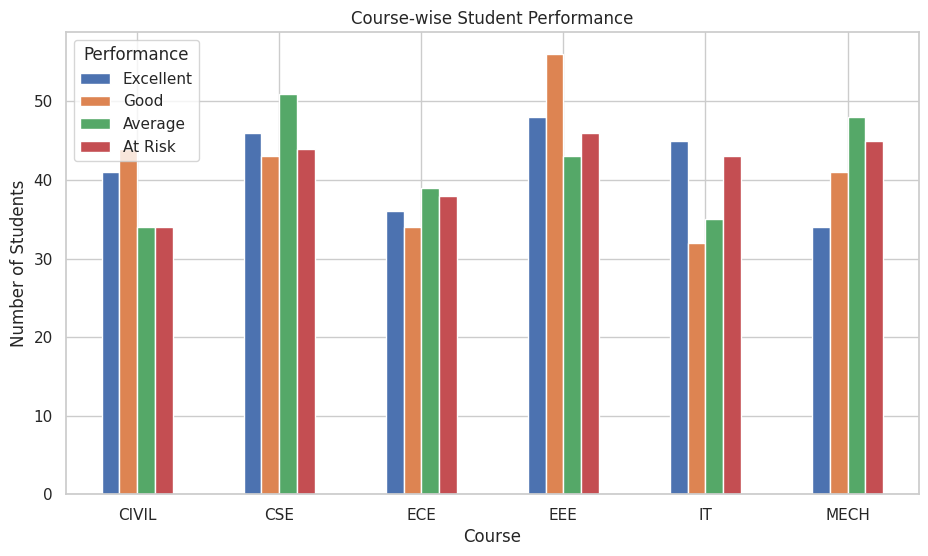

In [ ]:
course_performance.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Course-wise Student Performance")
plt.xlabel("Course")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Performance")

plt.show()

In [ ]:
# Identify declining engagement
df_clean["Low_Assignment"] = (
    df_clean["Assignment_Submissions"] < 60
)

df_clean["Low_Platform_Activity"] = (
    df_clean["Learning_Platform_Activity"] < 60
)

df_clean["Low_Previous_Performance"] = (
    df_clean["Previous_Performance"] < 60
)

df_clean["At_Risk_Performance"] = (
    df_clean["Performance_Status"] == "At Risk"
)

df_clean["Risk_Indicators"] = (
    df_clean["Low_Assignment"].astype(int)
    + df_clean["Low_Platform_Activity"].astype(int)
    + df_clean["Low_Previous_Performance"].astype(int)
    + df_clean["At_Risk_Performance"].astype(int)
)

def risk_level(x):
    if x >= 3:
        return "High"
    elif x == 2:
        return "Medium"
    elif x == 1:
        return "Low"
    else:
        return "Normal"

df_clean["Risk_Level"] = df_clean["Risk_Indicators"].apply(
    risk_level
)

risk_students = df_clean[
    df_clean["Risk_Level"].isin(["High", "Medium"])
].copy()

print("Potential students requiring academic attention:")
display(
    risk_students[
        [
            "Student_ID",
            "Attendance",
            "Assignment_Submissions",
            "Learning_Platform_Activity",
            "Previous_Performance",
            "Performance_Status",
            "Risk_Level"
        ]
    ].head(20)
)

Potential students requiring academic attention:


,Student_ID,Attendance,Assignment_Submissions,Learning_Platform_Activity,Previous_Performance,Performance_Status,Risk_Level
2,STU0003,78.8,43.3,57.0,58.7,Average,High
8,STU0009,75.9,38.8,40.5,55.2,At Risk,High
10,STU0011,76.2,45.4,37.5,54.8,At Risk,High
13,STU0014,78.2,41.7,32.4,47.7,At Risk,High
14,STU0015,77.5,36.2,42.9,39.4,At Risk,High
15,STU0016,77.2,39.6,30.4,43.5,At Risk,High
17,STU0018,78.8,39.9,50.1,31.8,At Risk,High
18,STU0019,79.2,45.5,42.0,41.7,At Risk,High
20,STU0021,81.6,44.6,48.0,72.0,Average,Medium
23,STU0024,81.4,54.1,66.3,55.5,Average,Medium


In [ ]:
# Engagement score
df_clean["Engagement_Score"] = (
    0.30 * df_clean["Attendance"]
    + 0.35 * df_clean["Assignment_Submissions"]
    + 0.35 * df_clean["Learning_Platform_Activity"]
)

def engagement_level(score):
    if score <= 60:
        return "Low"
    elif score <= 75:
        return "Medium"
    else:
        return "High"

df_clean["Engagement_Level"] = (
    df_clean["Engagement_Score"]
    .apply(engagement_level)
)

display(
    df_clean[
        [
            "Student_ID",
            "Engagement_Score",
            "Engagement_Level"
        ]
    ].head(10)
)

,Student_ID,Engagement_Score,Engagement_Level
0,STU0001,66.055,Medium
1,STU0002,65.920,Medium
2,STU0003,58.745,Low
3,STU0004,69.035,Medium
4,STU0005,71.155,Medium
5,STU0006,67.455,Medium
6,STU0007,66.185,Medium
7,STU0008,69.305,Medium
8,STU0009,50.525,Low
9,STU0010,87.975,High


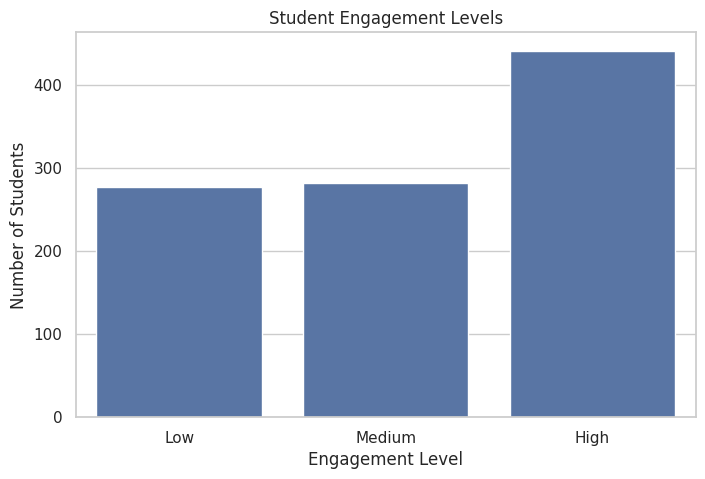

In [ ]:
# Visualization
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Engagement_Level",
    order=["Low", "Medium", "High"]
)

plt.title("Student Engagement Levels")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
# Generate 5–7 data-driven insights
performance_order = [
    "Excellent",
    "Good",
    "Average",
    "At Risk"
]

avg_attendance = (
    df_clean
    .groupby("Performance_Status")["Attendance"]
    .mean()
    .reindex(performance_order)
)

avg_internal = (
    df_clean
    .groupby("Performance_Status")["Internal_Marks"]
    .mean()
    .reindex(performance_order)
)

avg_assignment = (
    df_clean
    .groupby("Performance_Status")["Assignment_Submissions"]
    .mean()
    .reindex(performance_order)
)

avg_activity = (
    df_clean
    .groupby("Performance_Status")["Learning_Platform_Activity"]
    .mean()
    .reindex(performance_order)
)

avg_previous = (
    df_clean
    .groupby("Performance_Status")["Previous_Performance"]
    .mean()
    .reindex(performance_order)
)

print("KEY DATA-DRIVEN INSIGHTS\n")

print(
    f"1. Average attendance ranges from "
    f"{avg_attendance.min():.2f}% to {avg_attendance.max():.2f}% "
    f"across performance groups."
)

print(
    f"2. Average internal marks are highest for "
    f"{avg_internal.idxmax()} students "
    f"({avg_internal.max():.2f})."
)

print(
    f"3. Average assignment submission is highest for "
    f"{avg_assignment.idxmax()} students "
    f"({avg_assignment.max():.2f}%)."
)

print(
    f"4. Average learning-platform activity is highest for "
    f"{avg_activity.idxmax()} students "
    f"({avg_activity.max():.2f}%)."
)

print(
    f"5. Average previous performance is highest for "
    f"{avg_previous.idxmax()} students "
    f"({avg_previous.max():.2f})."
)

print(
    f"6. {len(risk_students)} students are classified as "
    f"Medium or High potential-risk based on the defined "
    f"engagement indicators."
)

print(
    f"7. Attendance vs Internal Marks correlation is "
    f"{correlation:.3f}."
)

KEY DATA-DRIVEN INSIGHTS

1. Average attendance ranges from 76.79% to 89.59% across performance groups.
2. Average internal marks are highest for Excellent students (85.98).
3. Average assignment submission is highest for Excellent students (88.45%).
4. Average learning-platform activity is highest for Excellent students (86.94%).
5. Average previous performance is highest for Excellent students (83.90).
6. 376 students are classified as Medium or High potential-risk based on the defined engagement indicators.
7. Attendance vs Internal Marks correlation is 0.726.


In [ ]:
# Prepare data for Random Forest
features = [
    "Attendance",
    "Internal_Marks",
    "Assignment_Submissions",
    "Learning_Platform_Activity",
    "Previous_Performance",
    "Course"
]

target = "Performance_Status"

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [ ]:
# Build Random Forest pipeline
numeric_features = [
    "Attendance",
    "Internal_Marks",
    "Assignment_Submissions",
    "Learning_Platform_Activity",
    "Previous_Performance"
]

categorical_features = [
    "Course"
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
#Model evaluation
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("MODEL EVALUATION")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

MODEL EVALUATION
-------------------------
Accuracy  : 0.9800
Precision : 0.9800
Recall    : 0.9800
F1 Score  : 0.9799


In [ ]:
#Classification report
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00        50
     Average       0.98      1.00      0.99        50
   Excellent       0.98      0.96      0.97        50
        Good       0.96      0.96      0.96        50

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



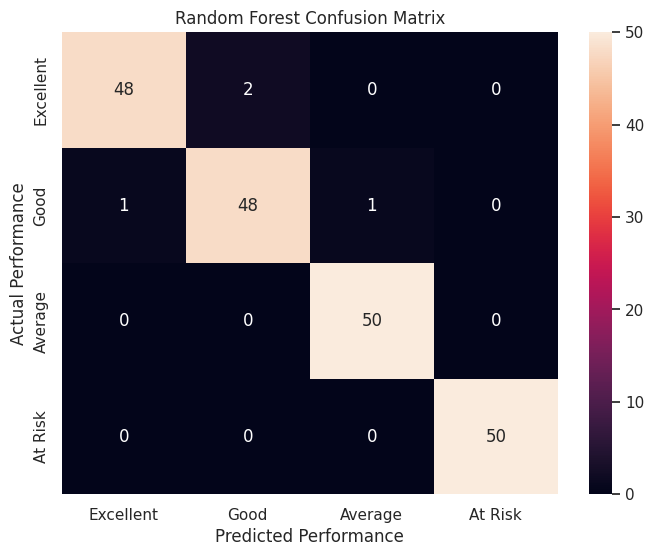

In [ ]:
# Confusion matrix
labels = [
    "Excellent",
    "Good",
    "Average",
    "At Risk"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Performance")
plt.ylabel("Actual Performance")

plt.show()

In [ ]:
# Feature importance
classifier = model.named_steps["classifier"]
preprocessor_fitted = model.named_steps["preprocessor"]

encoded_features = (
    preprocessor_fitted
    .named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

feature_names = (
    numeric_features +
    list(encoded_features)
)

importances = classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Internal_Marks,0.277180
2,Assignment_Submissions,0.260232
3,Learning_Platform_Activity,0.200450
4,Previous_Performance,0.143633
0,Attendance,0.101207
9,Course_IT,0.003709
7,Course_ECE,0.003204
8,Course_EEE,0.002856
6,Course_CSE,0.002750
10,Course_MECH,0.002737


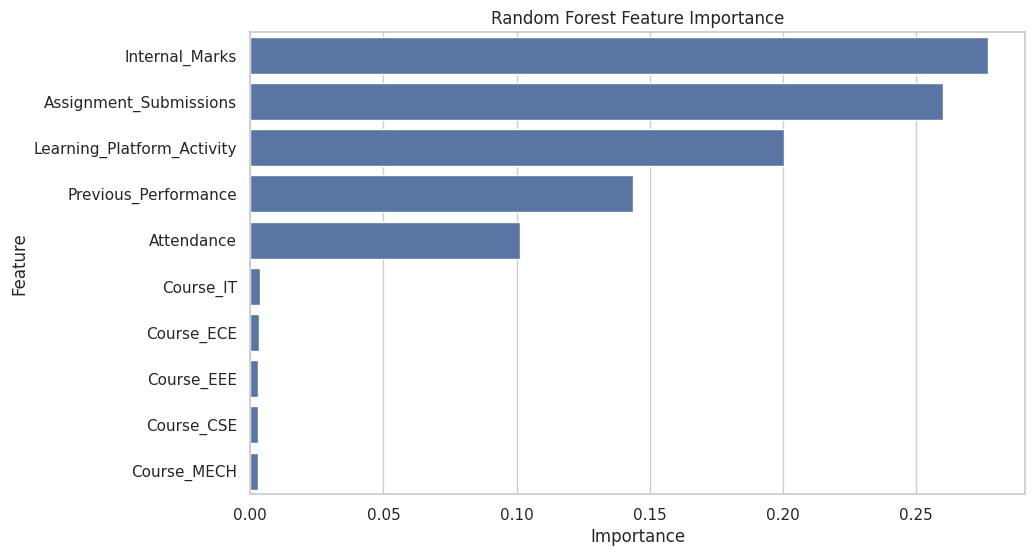

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# Test prediction for one student
sample_student = pd.DataFrame({
    "Attendance": [82],
    "Internal_Marks": [64],
    "Assignment_Submissions": [55],
    "Learning_Platform_Activity": [48],
    "Previous_Performance": [58],
    "Course": ["CSE"]
})

prediction = model.predict(sample_student)

probabilities = model.predict_proba(sample_student)

print("Predicted Performance:", prediction[0])

print("\nPrediction Probabilities:")

for label, probability in zip(
    model.classes_,
    probabilities[0]
):
    print(f"{label}: {probability:.2%}")

Predicted Performance: Average

Prediction Probabilities:
At Risk: 0.50%
Average: 99.50%
Excellent: 0.00%
Good: 0.00%


In [ ]:
# Academic support intervention plan
print("ACADEMIC SUPPORT INTERVENTION PLAN")
print("=" * 45)

print("""
1. Low Assignment Submission
   → Provide assignment reminders and weekly submission tracking.

2. Low Learning Platform Activity
   → Encourage regular LMS usage and provide structured learning
     activities or recommended resources.

3. Low Previous Performance
   → Provide additional practice sessions, mentoring and revision
     materials.

4. Medium/High Engagement Risk
   → Assign academic mentors and monitor the student periodically.

5. At-Risk Performance
   → Conduct early academic counselling and create an
     individualized improvement plan.

6. Course-Level Differences
   → Investigate course-specific learning difficulties and provide
     targeted support where required.
""")

ACADEMIC SUPPORT INTERVENTION PLAN

1. Low Assignment Submission
   → Provide assignment reminders and weekly submission tracking.

2. Low Learning Platform Activity
   → Encourage regular LMS usage and provide structured learning
     activities or recommended resources.

3. Low Previous Performance
   → Provide additional practice sessions, mentoring and revision
     materials.

4. Medium/High Engagement Risk
   → Assign academic mentors and monitor the student periodically.

5. At-Risk Performance
   → Conduct early academic counselling and create an
     individualized improvement plan.

6. Course-Level Differences
   → Investigate course-specific learning difficulties and provide
     targeted support where required.



In [ ]:
# Save trained model
joblib.dump(
    model,
    "student_performance_random_forest.joblib"
)

# Save cleaned dataset
df_clean.to_csv(
    "cleaned_student_performance.csv",
    index=False
)

# Save potential risk students
risk_students.to_csv(
    "at_risk_students.csv",
    index=False
)

# Save model metrics
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df.to_csv(
    "model_metrics.csv",
    index=False
)

# Save feature importance
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("All project outputs saved successfully.")

All project outputs saved successfully.


In [ ]:
files.download("student_performance_random_forest.joblib")

In [ ]:
files.download("cleaned_student_performance.csv")

In [ ]:
files.download("at_risk_students.csv")

In [ ]:
files.download("model_metrics.csv")

In [ ]:
files.download("feature_importance.csv")